# This notebook will run LoG on phantom and clinical US data #

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [4]:
def LoG_filter_opencv(image, sigma, size=None):
    # Generate LoG kernel
    if size is None:
        size = int(6 * sigma + 1) if sigma >= 1 else 7

    if size % 2 == 0:
        size += 1

    x, y = np.meshgrid(np.arange(-size//2+1, size//2+1), np.arange(-size//2+1, size//2+1))
    kernel = -(1/(np.pi * sigma**4)) * (1 - ((x**2 + y**2) / (2 * sigma**2))) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / np.sum(np.abs(kernel))

    # Perform convolution using OpenCV filter2D
    result = cv2.filter2D(image, -1, kernel)

    return result


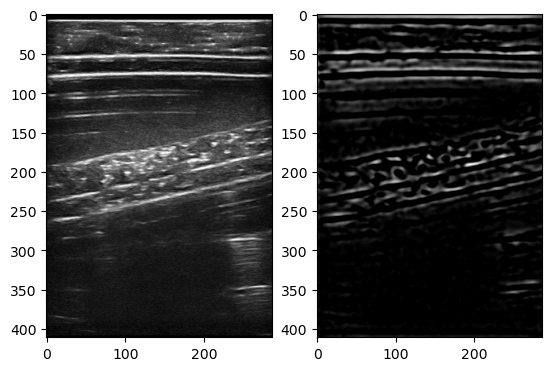

In [9]:
plt.subplot(1, 2, 1)
image = cv2.imread('../local_data/train_data/capture_1_2023-02-10T16-26-47.jpeg', cv2.IMREAD_GRAYSCALE) 
plt.imshow(image,cmap='gray')
sigma = 3.0
filtered_image = LoG_filter_opencv(image, sigma)
filtered_image = cv2.convertScaleAbs(filtered_image)

plt.subplot(1, 2, 2)
plt.imshow(filtered_image, cmap="gray")
plt.show()

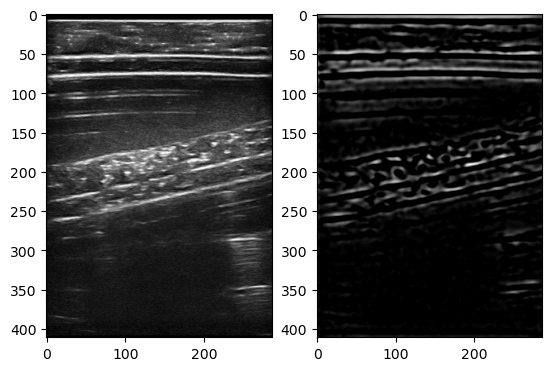

In [8]:
plt.subplot(1, 2, 1)
image = cv2.imread('../local_data/train_data/capture_1_2023-02-10T16-26-47.jpeg', cv2.IMREAD_GRAYSCALE) 
plt.imshow(image,cmap='gray')
sigma = 3
filtered_image = LoG_filter_opencv(image, sigma)
filtered_image = cv2.convertScaleAbs(filtered_image)

plt.subplot(1, 2, 2)
plt.imshow(filtered_image, cmap="gray")
plt.show()